In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from sqlalchemy import create_engine, text

# Connect to DB
engine = create_engine("sqlite:///../db/retail.db")

In [2]:
# Test connection
test = pd.read_sql("SELECT COUNT(*) AS rows FROM online_retail", engine)
test

,rows
0,805549


In [3]:
# Monthly revenue

query = """
SELECT strftime('%Y-%m', invoicedate) AS year_month,
        SUM(totalprice) AS total_revenue,
        COUNT(DISTINCT invoice) AS orders
FROM online_retail
WHERE invoicedate IS NOT NULL
GROUP BY year_month
ORDER BY year_month;
"""

monthly_revenue = pd.read_sql(query, engine)
monthly_revenue

,year_month,total_revenue,orders
0,2009-01,44048.690,98
1,2009-02,52941.990,110
2,2009-03,67479.080,122
3,2009-04,34064.410,80
4,2009-05,9803.050,30
5,2009-06,24580.720,72
6,2009-07,33169.630,94
7,2009-08,44804.340,102
8,2009-09,31113.600,77
9,2009-10,38806.360,87


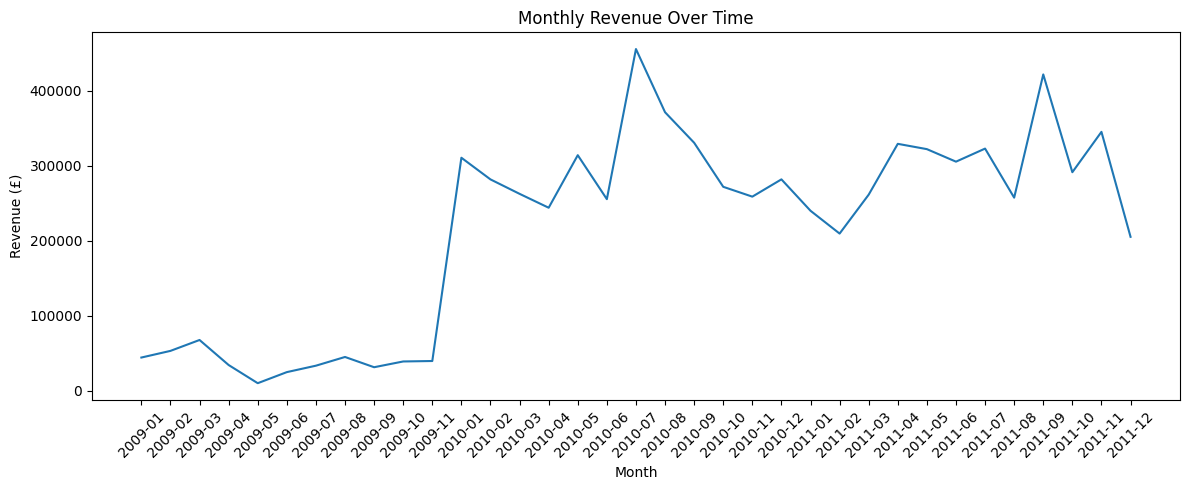

In [4]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue["year_month"], monthly_revenue["total_revenue"])
plt.xticks(rotation=45)
plt.title("Monthly Revenue Over Time")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.tight_layout()
plt.show()

In [5]:
fig = px.line(monthly_revenue, x="year_month", y="total_revenue", title="Monthly Revenue", markers=True)
fig.show()
fig.write_html("../outputs/figures/monthly_revenue.html")

In [6]:
%pip install --upgrade kaleido

Note: you may need to restart the kernel to use updated packages.


In [7]:
# Top products

query = """
SELECT description AS product,
        SUM(totalprice) AS total_revenue,
        SUM(quantity) AS total_quantity
FROM online_retail
GROUP BY description
ORDER BY total_revenue DESC
LIMIT 10;
"""

top_products = pd.read_sql(query, engine)
top_products

,product,total_revenue,total_quantity
0,REGENCY CAKESTAND 3 TIER,286486.30,24899
1,WHITE HANGING HEART T-LIGHT HOLDER,252072.46,93640
2,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995
3,Manual,152340.57,9803
4,JUMBO BAG RED RETROSPOT,136980.08,75759
5,ASSORTED COLOUR BIRD ORNAMENT,127074.17,79913
6,POSTAGE,126563.04,5333
7,PARTY BUNTING,103880.23,23607
8,MEDIUM CERAMIC TOP STORAGE JAR,81416.73,77916
9,PAPER CHAIN KIT 50'S CHRISTMAS,79594.33,29477


In [8]:
fig = px.bar(top_products, x="product", y="total_revenue", title="Top 10 Products by Revenue", text="total_revenue")
fig.show()
fig.write_image("../outputs/figures/top_products.png")

In [9]:
# Customer Lifetime Value

query = """
SELECT customer_id,
        SUM(totalprice) AS lifetime_value,
        COUNT(DISTINCT invoice) AS orders
FROM online_retail
WHERE customer_id IS NOT NULL
GROUP BY customer_id
ORDER BY lifetime_value DESC
LIMIT 20;
"""

customer_lifetime_value = pd.read_sql(query, engine)
customer_lifetime_value

,customer_id,lifetime_value,orders
0,18102,608821.65,145
1,14646,528602.52,151
2,14156,313946.37,156
3,14911,295972.63,398
4,17450,246973.09,51
5,13694,196482.81,143
6,17511,175603.55,60
7,16446,168472.50,2
8,16684,147142.77,55
9,12415,144458.37,28


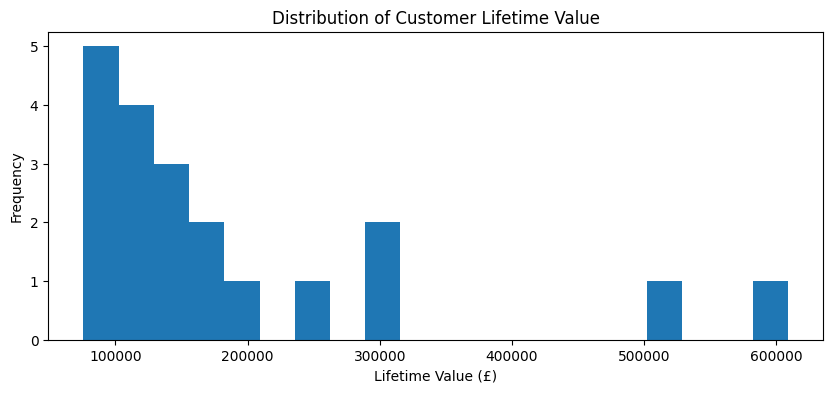

In [10]:
plt.figure(figsize=(10, 4))
plt.hist(customer_lifetime_value["lifetime_value"], bins=20)
plt.title("Distribution of Customer Lifetime Value")
plt.xlabel("Lifetime Value (£)")
plt.ylabel("Frequency")
plt.show()

In [11]:
fig = px.scatter(customer_lifetime_value, x="orders", y="lifetime_value", title="Customer Lifetime Value vs. Number of Orders")
fig.show()

In [12]:
# Revenue by country

query = """
SELECT country,
        SUM(totalprice) AS total_revenue,
        COUNT(DISTINCT customer_id) AS customers
FROM online_retail
GROUP BY country
ORDER BY total_revenue DESC
LIMIT 10;
"""
country_revenue = pd.read_sql(query, engine)
country_revenue

,country,total_revenue,customers
0,United Kingdom,1.472315e+07,5350
1,EIRE,6.216311e+05,5
2,Netherlands,5.542323e+05,22
3,Germany,4.312625e+05,107
4,France,3.552575e+05,95
5,Australia,1.699681e+05,15
6,Spain,1.091785e+05,41
7,Switzerland,1.003653e+05,22
8,Sweden,9.154972e+04,19
9,Denmark,6.986219e+04,12


In [15]:
fig = px.bar(country_revenue, x="country", y="total_revenue", title="Total Revenue by Country")
fig.update_layout(xaxis_tickangle=-45)
fig.show()

In [16]:
# Export tables to CSV

monthly_revenue.to_csv("../outputs/monthly_revenue.csv", index=False)
top_products.to_csv("../outputs/top_products.csv", index=False)
customer_lifetime_value.to_csv("../outputs/customer_lifetime_value.csv", index=False)
country_revenue.to_csv("../outputs/country_revenue.csv", index=False)